In [1]:
from datasets import load_dataset
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn
import torch.nn.functional as f
from torch.utils.data import Dataset,DataLoader
from torchvision.transforms import ToTensor

d:\Project\ACL\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from datasets import load_dataset
ds = load_dataset("akar49/MRI_Segmentation-1")
train_set=ds["train"]
valid_set=ds["validation"]


In [3]:
train_zero=train_set['image'][0]
zero_seg=train_set['label'][100]
print(zero_seg.size)

(512, 512)


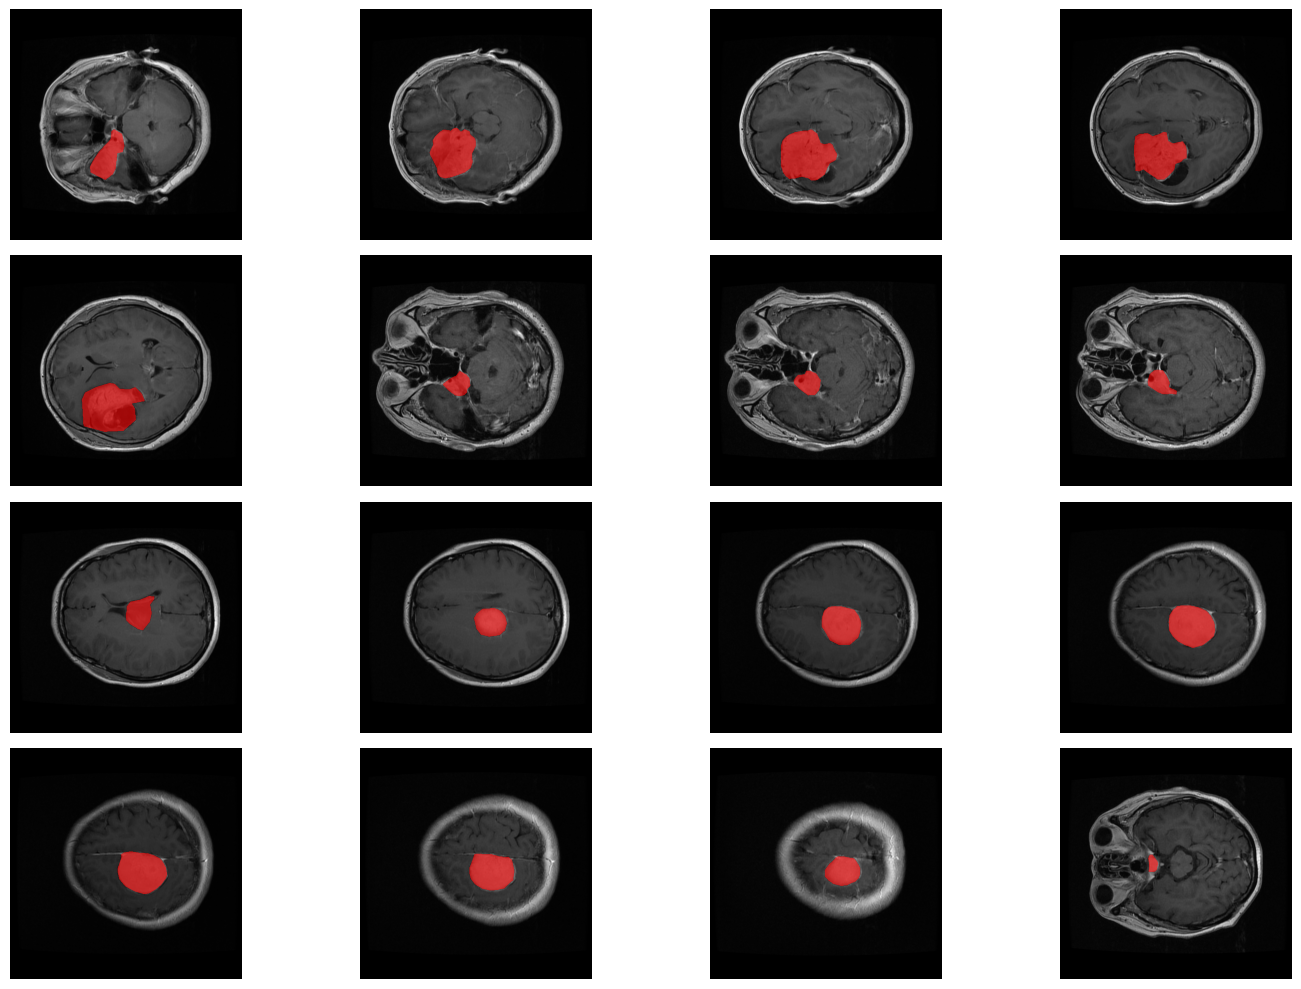

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

# Define a colormap with transparency for background
# RGBA format
cmap = ListedColormap([
    (0, 0, 0, 0),       # class 0 → transparent
    (1, 0, 0, 0.6),     # class 1 → red
    (1, 1, 0, 0.6),     # class 2 → green
    (1, 0, 0, 0.6)      # class 3 → yellow
])

n_shows = 16
cols = 4
rows = 4

plt.figure(figsize=(15,10))

for i in range(n_shows):
    img = train_set["image"][i]
    label = train_set["label"][i]   # label must be integers 0–3
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img, cmap="gray")       # clear grayscale
    plt.imshow(label, cmap=cmap)       # crisp segmentation overlay
    plt.axis("off")

plt.tight_layout()
plt.show()


In [5]:
class BrainTumorSegment(Dataset):
    def __init__(self,dataset,img_transform=None,label_transform=None,target_size=(512,512)):
        self.dataset=dataset
        self.label_transform=label_transform
        self.img_transform=img_transform
        self.target_size=target_size
    def __len__(self):
        return len(self.dataset['image'])
    def __getitem__(self, index):
        img =self.dataset['image'][i]
        label=self.dataset['label'][i]
        if self.img_transform:
            img =self.img_transform(img)
        if self.label_transform:
            label=self.label_transform(label)
        return img, label


In [6]:
transform=ToTensor()

In [7]:
BrainMRI_train=BrainTumorSegment(train_set,img_transform=transform,label_transform=transform)
BrainMRI_val=BrainTumorSegment(valid_set,img_transform=transform,label_transform=transform)

In [8]:
train_dataloader = DataLoader(BrainMRI_train, batch_size=64, shuffle=True)
test_dataloader = DataLoader(BrainMRI_val, batch_size=64, shuffle=True)

In [9]:
print(train_dataloader.dataset[0][1].shape)
print(test_dataloader.dataset[0][1].shape)

torch.Size([1, 512, 512])
torch.Size([1, 512, 512])
